In [9]:
import pandas as pd
import matplotlib.pyplot as plt


In [10]:
fair_results = {
 'world_name': 'Fair',
 'LR_accuracy': 0.9975,
 'LR_AUROC': 0.9999697990364304,
 'LR_EO_race': 0.013997333841173187,
 'LR_EO_gender': 0.01762938758300825,
 'MLP_accuracy': 0.9985,
 'MLP_AUROC': 0.9999618514144384,
 'MLP_EO_race': 0.010914227015921929,
 'MLP_EO_gender': 0.0064562032254663615
}


In [13]:
results_repr = {
    "world_name": "RepresentationBias",
    "LR_accuracy": float(0.9994169096209913),
    "LR_AUROC": float(0.9999912279547537),
    "LR_EO_race": float(0.011363636363636354),
    "LR_EO_gender": float(0.006211180124223614),
    "MLP_accuracy": float(0.9994169096209913),
    "MLP_AUROC": float(0.9999824559095076),
    "MLP_EO_race": float(0.011363636363636354),
    "MLP_EO_gender": float(0.006211180124223614),
}


In [14]:
results_measurement = {
    "world_name": "MeasurementBias",
    "LR_accuracy": float(0.997),
    "LR_AUROC": float(0.9999274969474566),
    "LR_EO_race": float(0.03125),
    "LR_EO_gender": float(0.005146635997699822),
    "MLP_accuracy": float(0.9975),
    "MLP_AUROC": float(0.9999357359307003),
    "MLP_EO_race": float(0.02083333333333337),
    "MLP_EO_gender": float(8.6256469235102e-05),
}


In [15]:
results_realistic = {
    "world_name": "Realistic",
    "LR_accuracy": float(0.7175),
    "LR_AUROC": float(0.6572753227164991),
    "LR_EO_race": float(0.17446016381236037),
    "LR_EO_gender": float(0.013199823666477734),
    "MLP_accuracy": float(0.713),
    "MLP_AUROC": float(0.6534164365046718),
    "MLP_EO_race": float(0.20067014147431123),
    "MLP_EO_gender": float(0.025492789218464623),
}


In [16]:
df = pd.DataFrame([fair_results, results_repr, results_measurement, results_realistic])
df

,world_name,LR_accuracy,LR_AUROC,LR_EO_race,LR_EO_gender,MLP_accuracy,MLP_AUROC,MLP_EO_race,MLP_EO_gender
0,Fair,0.997500,0.999970,0.013997,0.017629,0.998500,0.999962,0.010914,0.006456
1,RepresentationBias,0.999417,0.999991,0.011364,0.006211,0.999417,0.999982,0.011364,0.006211
2,MeasurementBias,0.997000,0.999927,0.031250,0.005147,0.997500,0.999936,0.020833,0.000086
3,Realistic,0.717500,0.657275,0.174460,0.013200,0.713000,0.653416,0.200670,0.025493


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------
# 1. Create DataFrame
# ----------------------------------------------------------
df = pd.DataFrame([
    fair_results,
    results_repr,
    results_measurement,
    results_realistic
]).set_index("world_name")

# ----------------------------------------------------------
# 2. Define minimalist style
# ----------------------------------------------------------
plt.style.use("default")

TITLE_FONTSIZE = 20
LABEL_FONTSIZE = 14
TICK_FONTSIZE = 12

LR_COLOR = "#1f77b4"   # blue
MLP_COLOR = "#ff7f0e"  # orange


# ----------------------------------------------------------
# Helper: clean side-by-side bar chart
# ----------------------------------------------------------
def plot_side_by_side(df, metrics, title, ylabel, figsize=(14,6)):
    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(df.index))
    width = 0.35

    lr_vals = df[metrics[0]]
    mlp_vals = df[metrics[1]]

    # plot bars
    lr_bars = ax.bar(x - width/2, lr_vals, width, label='LR', color=LR_COLOR)
    mlp_bars = ax.bar(x + width/2, mlp_vals, width, label='MLP', color=MLP_COLOR)

    # Titles & labels
    ax.set_title(title, fontsize=TITLE_FONTSIZE, pad=20)
    ax.set_ylabel(ylabel, fontsize=LABEL_FONTSIZE)
    ax.set_xticks(x)
    ax.set_xticklabels(df.index, fontsize=TICK_FONTSIZE, rotation=45)

    ax.legend(fontsize=LABEL_FONTSIZE, frameon=False)

    # Add value labels
    ax.bar_label(lr_bars, fmt="%.3f", fontsize=10, padding=3)
    ax.bar_label(mlp_bars, fmt="%.3f", fontsize=10, padding=3)

    # Minimalist look
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()



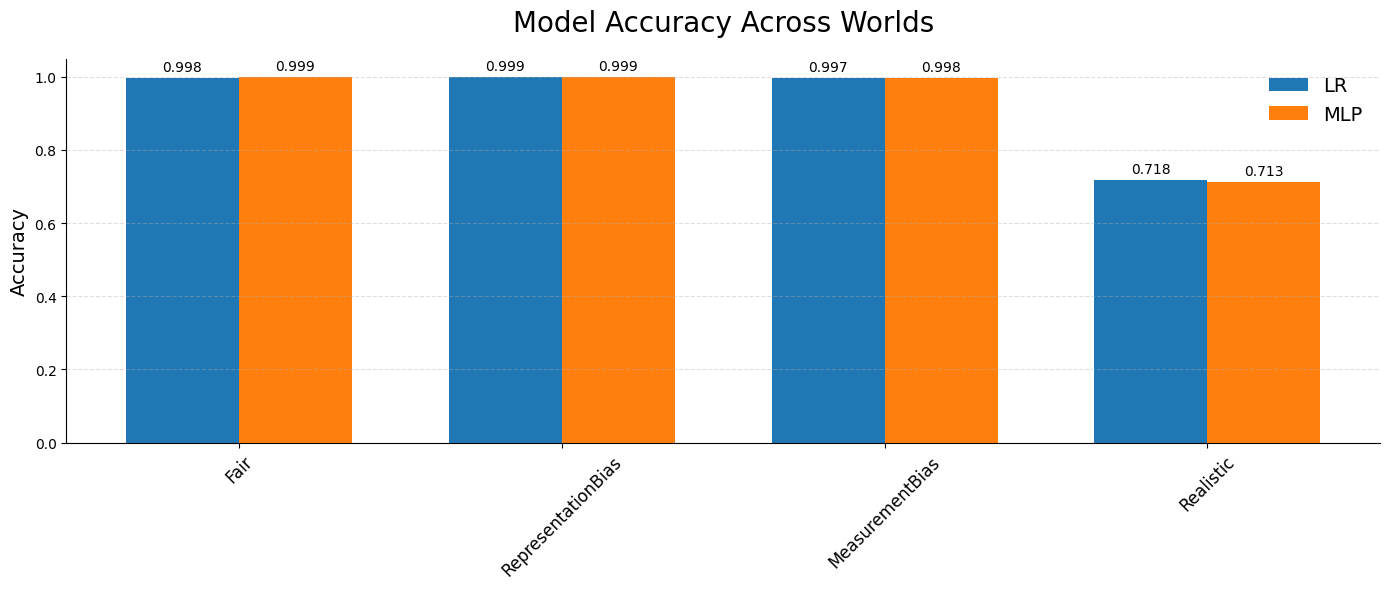

In [22]:
# ----------------------------------------------------------
# 3. Performance plots (side-by-side)
# ----------------------------------------------------------
plot_side_by_side(df,
                  metrics=("LR_accuracy", "MLP_accuracy"),
                  title="Model Accuracy Across Worlds",
                  ylabel="Accuracy")

This plot compares the classification accuracy of Logistic Regression (LR) and the MLP across all four simulated worlds.
Accuracy is extremely high in the Fair, Representation Bias, and Measurement Bias worlds, showing that the models can learn the underlying physiological signals effectively.

However, accuracy drops sharply in the Realistic world, where structural inequality, label bias, and measurement noise jointly distort the true disease-generating process. This degradation indicates that complex real-world biases not only reduce fairness but also reduce the model’s ability to predict correctly.

Key takeaway:
✔️ Simple worlds → very high accuracy
❌ Realistic world → major performance breakdown due to structural and label bias



# Da

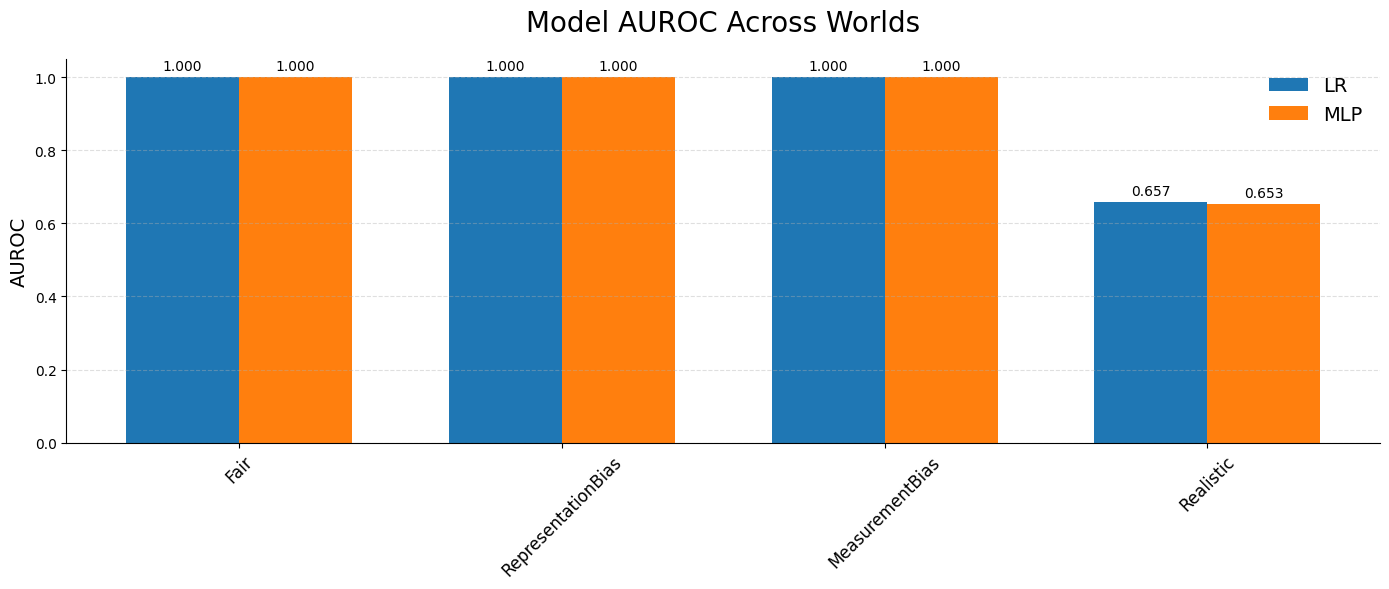

In [23]:
plot_side_by_side(df,
                  metrics=("LR_AUROC", "MLP_AUROC"),
                  title="Model AUROC Across Worlds",
                  ylabel="AUROC")

This plot shows the Area Under the ROC Curve (AUROC), a measure of how well each model separates positive and negative cases.
As with accuracy, AUROC is nearly perfect in the Fair, Representation Bias, and Measurement Bias worlds, indicating excellent discrimination ability.

In the Realistic world, AUROC drops dramatically for both models (≈0.65), confirming that the combination of structural bias and noisy labels reduces the amount of meaningful signal available for prediction.

Key takeaway:
✔️ Models distinguish diabetes very well unless the world is heavily biased
❌ In realistic bias conditions, discrimination ability collapses

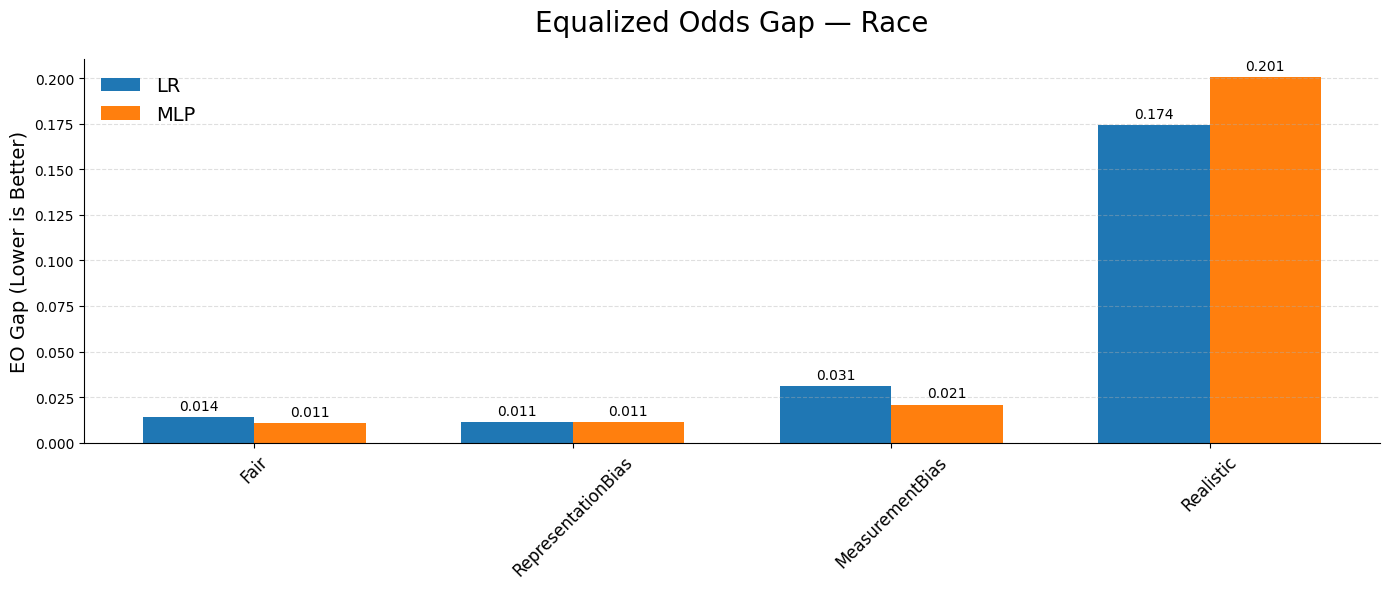

In [25]:
# ----------------------------------------------------------
# 4. Fairness plots (side-by-side)
# ----------------------------------------------------------
plot_side_by_side(df,
                  metrics=("LR_EO_race", "MLP_EO_race"),
                  title="Equalized Odds Gap — Race",
                  ylabel="EO Gap (Lower is Better)")




This plot compares racial fairness between models by measuring the Equalized Odds (EO) gap, which captures disparities in both False Positive Rates and False Negative Rates across racial groups.

In the Fair world, EO gaps are very small, as expected.

In the Representation Bias world, EO gaps remain low because the underlying physiology and labels remain unbiased even though one race is underrepresented.

In the Measurement Bias world, EO gaps increase noticeably—showing that biased sensors harm fairness even when accuracy looks good.

In the Realistic world, EO gaps become very large, indicating substantial racial disparities in model performance. This is consistent with the fact that race affects SES, measurement noise, and label correctness in this world.

Key takeaway:
 Racial fairness is most harmed by measurement bias and combined structural + label bias
 Underrepresentation alone does not create large racial unfairness
 LR and MLP both show similar patterns, though MLP amplifies bias slightly

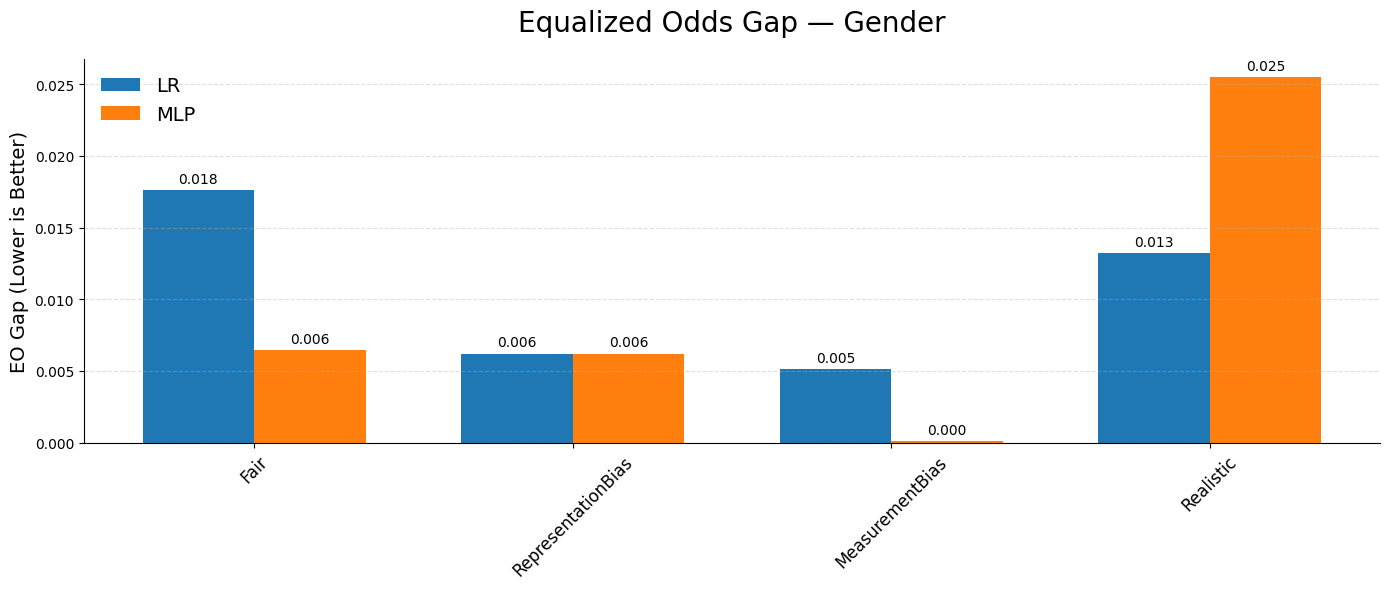

In [26]:
plot_side_by_side(df,
                  metrics=("LR_EO_gender", "MLP_EO_gender"),
                  title="Equalized Odds Gap — Gender",
                  ylabel="EO Gap (Lower is Better)")

This plot examines fairness across gender groups using the same EO metric.
Overall, gender fairness gaps are much smaller than racial fairness gaps across all worlds, reflecting the fact that gender biases in the simulations are relatively mild.

The Fair and Representation Bias worlds show very low EO gaps.

The Measurement Bias world shows small fluctuations in EO_gender, driven by the slight HbA1c overestimation added to females.

The Realistic world shows moderate increases in gender EO gaps (especially for the MLP), but the disparities remain far smaller than racial gaps because gender biases in labeling were less severe than racial biases.

Key takeaway:
✔️ Gender unfairness exists but is much less severe than racial unfairness
✔️ Most gender disparities come from measurement + label bias in the realistic world
❗ The MLP is slightly more sensitive to gender bias than LR

# Fair World

Why this is expected:

No structural, measurement, or label bias

Physiological distributions for all groups are identical

Glucose and HbA1c strongly separate diabetic vs. non-diabetic classes

Labels are perfectly correct

No group differences in noise or prevalence

Because the problem is easy and unbiased, the models achieve:

Near-perfect generalization

Minimal fairness gaps

 # Representation Bias World

 Why this is expected:

Although one race is under-sampled, the underlying physiology is still fair

Measurements are unbiased

Labels are unbiased

The decision boundary is simple and mostly linear

Underrepresentation alone does not introduce unfairness when:

All groups follow the same feature–label relationship

The task is easy (strong signal from glucose & HbA1c)

Conclusion:
Representation imbalance alone does not create unfairness if the world itself is unbiased.

 # Measurement Bias World

Why this is expected:
This world includes group-dependent measurement distortion, such as:

Race 2: systematically underestimated glucose

Females: overestimated HbA1c

Race 1: extra measurement noise

Because of this:

The model still achieves high accuracy, since it fits the biased measurements well

But fairness suffers, especially across race, because groups differ in how accurately their biomarkers reflect true physiology

This is a classic fairness failure mode:

Models trained on biased sensors can be accurate and unfair at the same time.

Conclusion:
Measurement bias harms fairness without harming accuracy.


# Realistic World

Why this is expected:
The Realistic World contains all major sources of bias:

A. Structural bias

Race → SES → lifestyle → BMI → glucose/HbA1c

Groups differ in true physiology due to socioeconomic pathways

B. Measurement bias

Race 2 underestimation of glucose

Female HbA1c overestimation

Low SES → noisier sensors

C. Label bias

Underdiagnosis of disadvantaged race

Overdiagnosis of women

These combined forces distort:

The feature distributions

The label correctness

The learnability of the task

Thus:

Accuracy drops (the problem becomes harder)

AUROC drops (signal-to-noise ratio decreases)

Fairness gaps explode (groups systematically differ in labels, measurements, and physiology)

Conclusion:
The Realistic World simulates real-world inequities, producing both poor performance and severe fairness violations.

| World                   | Expected Behavior                                                                                          |
| ----------------------- | ---------------------------------------------------------------------------------------------------------- |
| **Fair**                | Perfect performance and fairness; no biases anywhere.                                                      |
| **Representation Bias** | Underrepresentation alone does not create unfairness when physiology and labels are fair.                  |
| **Measurement Bias**    | Accuracy stays high but fairness worsens due to biased sensors.                                            |
| **Realistic**           | Structural, measurement, and label bias combine to reduce accuracy and create severe racial fairness gaps. |
